In [1]:
# ruff: noqa: F405

from _shared import pl_k_sP, remyelin_ds, run_deg_groups, run_nmf, run_proc_per_ds, viz_defs, comp_spat_stats  # isort:skip

from functools import partial
from pathlib import Path
from pickle import dump, load
from warnings import catch_warnings, simplefilter

import anndata as ad
import numpy as np
import scanpy as sc
import uapl
import upsetplot as up
from matplotlib import pyplot as plt
from plotnine import *  # noqa: F403

import spatialpeeler as sP
from spatialpeeler.diag import comp_sparsity, sweep_uns

In [2]:
viz_defs(dpi=128)
RAND_SEED = 28
# define helper function for plotting
pl_help = partial(pl_k_sP, cond_col="Condition", sample_col="puck_id", ctl_val="Saline", sp_p_size=0.3)
SP_FACT_PAT_STR = "sP_p_hat_k={k}"
SP_GENE_PAT_STR = "sp_gene_id_k={k}"

In [3]:
# load dataset + run NMF
if (pth := Path("../.cache/rml.pkl")).exists():
    with open(pth, "rb") as f:
        rml = load(f)
else:
    adatas = remyelin_ds(
        Path("../data/remyelin-slideseq"),
        # load only subset of interest
        lambda obs: (
            (obs["GoodQuality"] == "Yes")
            & (
                ((obs["Timepoint"].isin([3])) & (obs["Condition"] == "LPC"))
                | (obs["Timepoint"].isin([12, 18]) & (obs["Condition"] == "Saline"))
            )
        ),
    )
    for e in adatas.values():
        sc.pp.filter_cells(e, min_counts=100)

    run_proc_per_ds(adatas)

    rml = ad.concat(adatas, label="puck_id", index_unique="_")
    sc.pp.filter_genes(rml, min_cells=rml.n_obs // 500)

    rml.var["SYMBOL"] = (
        sc.queries.biomart_annotations("mmusculus", ["ensembl_gene_id", "external_gene_name"])
        .set_index("ensembl_gene_id")
        .merge(rml.var.index.to_series(), left_index=True, right_index=True, how="right")["external_gene_name"]
        .fillna(rml.var.index.to_series())
    )

    rml.obs["puck_id_cond"] = rml.obs["puck_id"].str.cat(rml.obs["Condition"], sep="_")
    rml.obs["Condition"] = rml.obs["Condition"].astype("category").cat.reorder_categories(["Saline", "LPC"])

    run_nmf(rml, 30, RAND_SEED)

    pth.parent.mkdir(exist_ok=True)
    with open(pth, "wb") as f:
        dump(rml, f)
print(rml)

AnnData object with n_obs × n_vars = 93450 × 12127
    obs: 'Sample details', 'Animal', 'Timepoint', 'Condition', 'GoodQuality', 'n_counts', 'puck_id', 'puck_id_cond'
    var: 'n_cells', 'SYMBOL'
    obsm: 'spatial', 'X_nmf'
    varm: 'X_nmf'
    layers: 'counts'


before proceeding with spatialPeeler, we inspect our count matrix and NMF factors to assess their sparsity

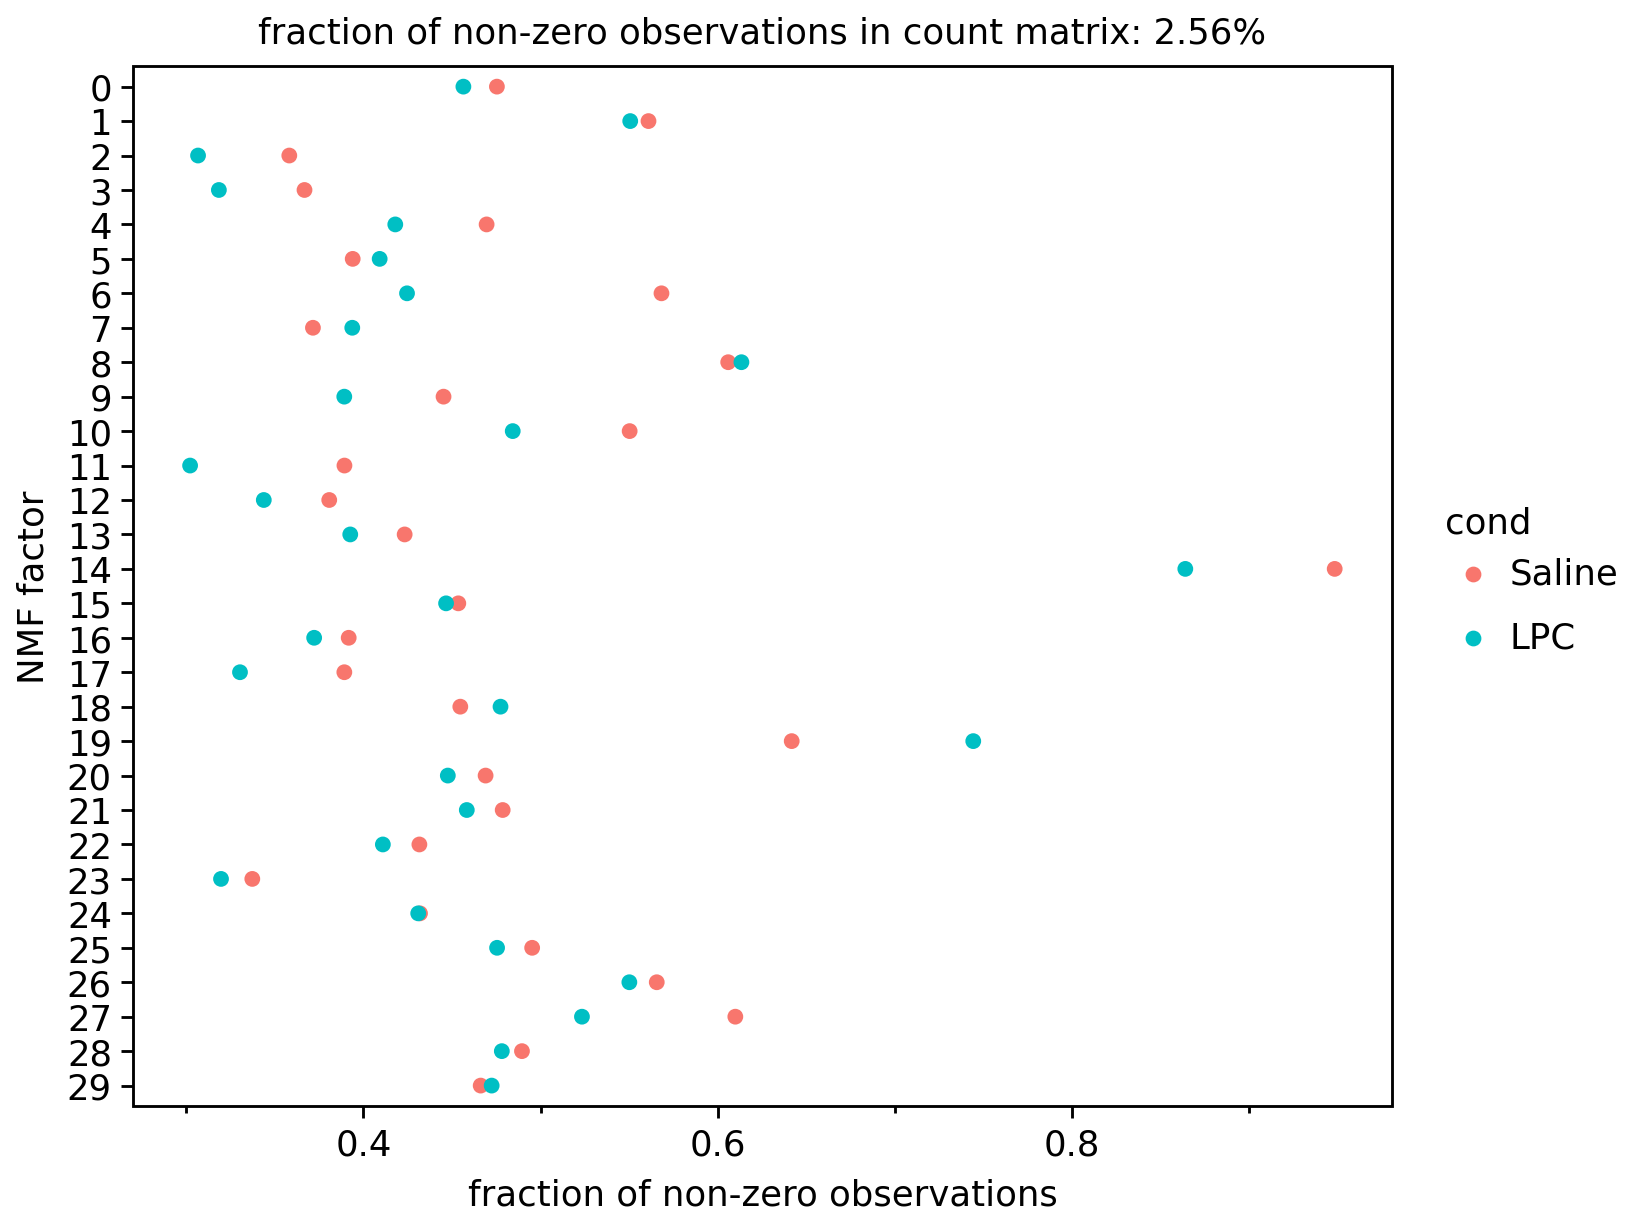

In [4]:
X_spars = rml.X.nnz / np.prod(rml.X.shape)  # ty:ignore[unresolved-attribute]
(
    comp_sparsity(rml.obsm["X_nmf"], cond=rml.obs["Condition"])
    >> ggplot()
    + aes(x="density", y="column", color="cond")
    + geom_point()
    + scale_y_discrete(limits=reversed)  # ty:ignore[invalid-argument-type]
    + labs(
        x="fraction of non-zero observations",
        y="NMF factor",
        title=f"fraction of non-zero observations in count matrix: {X_spars * 100:.02f}%",
    )
).show()

we see that the dataset is overall quite sparse (only ~1% of the data is non zero)
and this is reflected in the factors, which are also mostly quite sparse \
as such, we threshold our factor regression analysis to only include cells which are non-sparse for that factor

In [5]:
# run factor-wise regression step
for k in range(rml.obsm["X_nmf"].shape[1]):
    sP.run_fact_reg(
        rml,
        "Condition",
        "Saline",
        k,
        SP_FACT_PAT_STR.format(k=k),
        X_key="X_nmf",
        filt=lambda adata: adata[adata.obsm["X_nmf"][:, k] > 0, :],
    )

print(rml)

AnnData object with n_obs × n_vars = 93450 × 12127
    obs: 'Sample details', 'Animal', 'Timepoint', 'Condition', 'GoodQuality', 'n_counts', 'puck_id', 'puck_id_cond'
    var: 'n_cells', 'SYMBOL'
    uns: 'sP_p_hat_k=0', 'sP_p_hat_k=1', 'sP_p_hat_k=2', 'sP_p_hat_k=3', 'sP_p_hat_k=4', 'sP_p_hat_k=5', 'sP_p_hat_k=6', 'sP_p_hat_k=7', 'sP_p_hat_k=8', 'sP_p_hat_k=9', 'sP_p_hat_k=10', 'sP_p_hat_k=11', 'sP_p_hat_k=12', 'sP_p_hat_k=13', 'sP_p_hat_k=14', 'sP_p_hat_k=15', 'sP_p_hat_k=16', 'sP_p_hat_k=17', 'sP_p_hat_k=18', 'sP_p_hat_k=19', 'sP_p_hat_k=20', 'sP_p_hat_k=21', 'sP_p_hat_k=22', 'sP_p_hat_k=23', 'sP_p_hat_k=24', 'sP_p_hat_k=25', 'sP_p_hat_k=26', 'sP_p_hat_k=27', 'sP_p_hat_k=28', 'sP_p_hat_k=29'
    obsm: 'spatial', 'X_nmf', 'sP_p_hat_k=0', 'sP_p_hat_k=1', 'sP_p_hat_k=2', 'sP_p_hat_k=3', 'sP_p_hat_k=4', 'sP_p_hat_k=5', 'sP_p_hat_k=6', 'sP_p_hat_k=7', 'sP_p_hat_k=8', 'sP_p_hat_k=9', 'sP_p_hat_k=10', 'sP_p_hat_k=11', 'sP_p_hat_k=12', 'sP_p_hat_k=13', 'sP_p_hat_k=14', 'sP_p_hat_k=15', 'sP_

we now assess our resulting regression outputs distributions \
we can extract and collate the model betas and other statistics using the sweep_uns function

/workspaces/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log


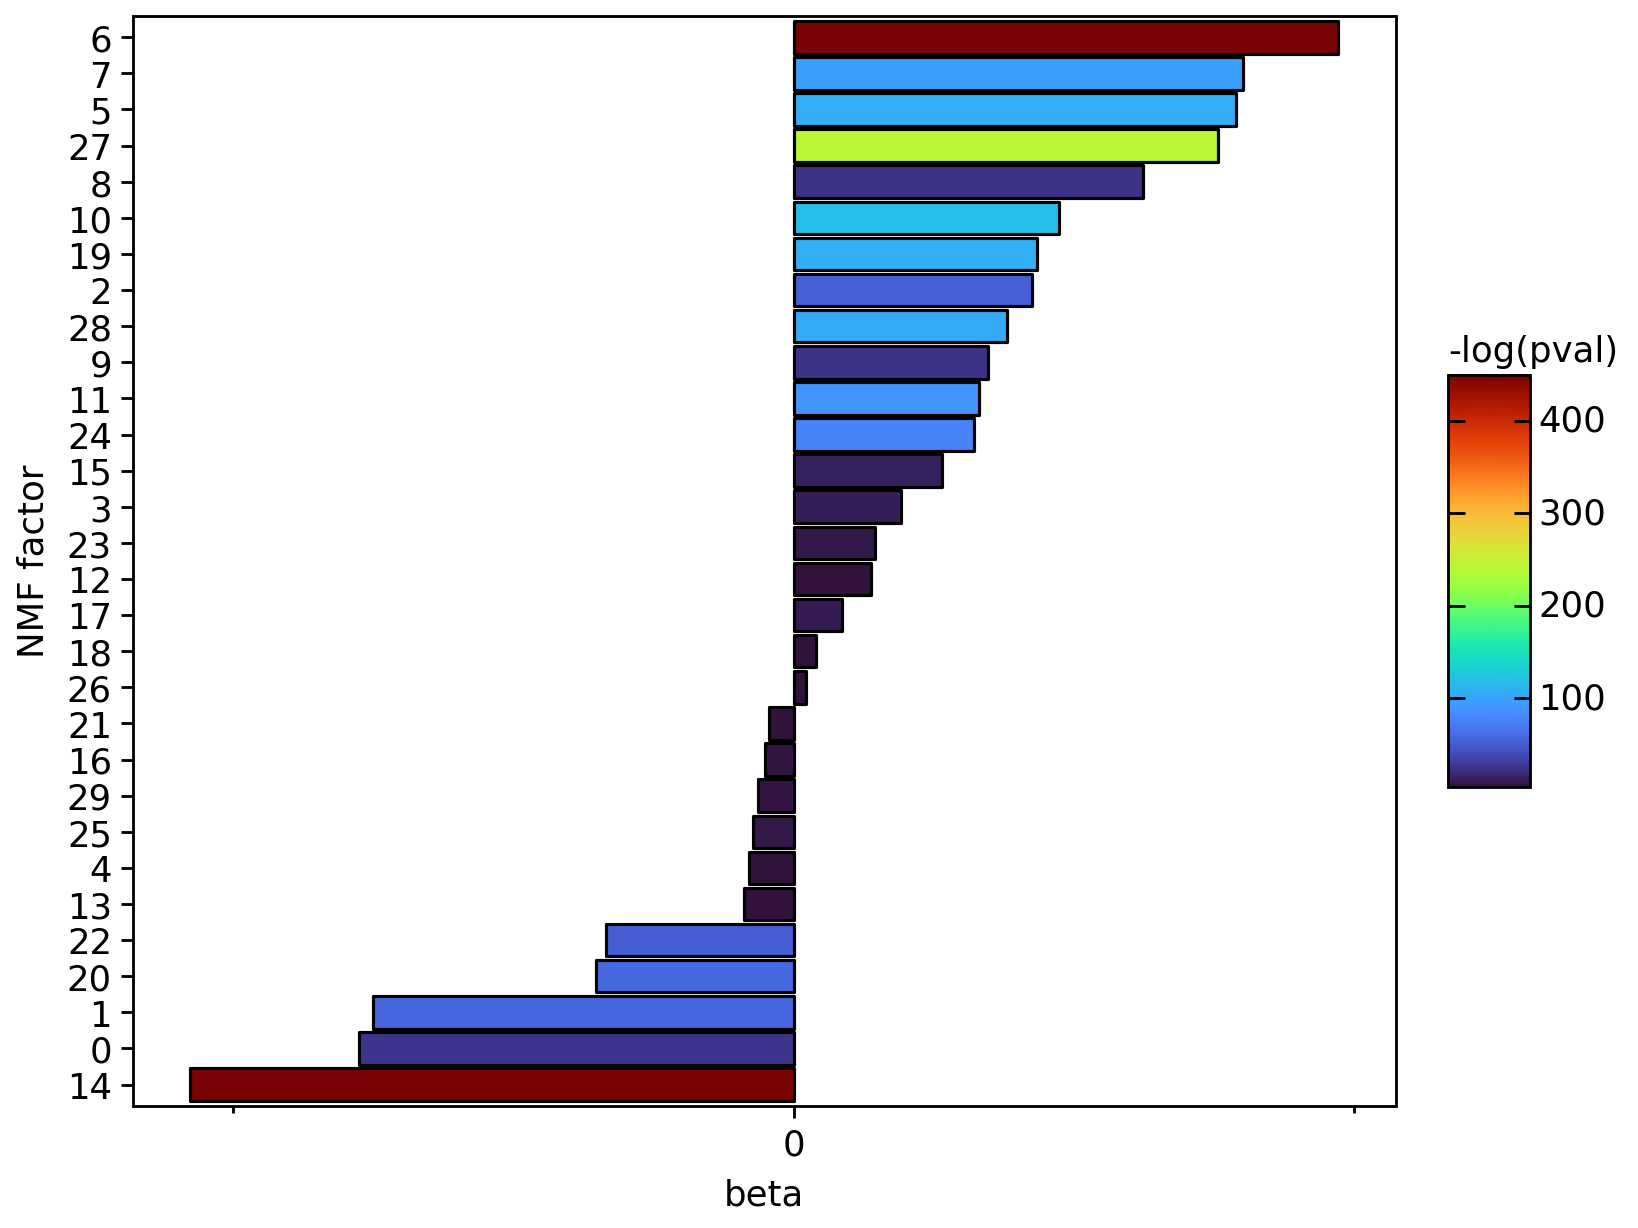

In [6]:
(
    sweep_uns(rml, SP_FACT_PAT_STR)
    >> ggplot()
    + aes(x="reorder(k, beta)", fill="-np.log(pval)", y="beta")
    + geom_col(color="black")
    + coord_flip()
    + labs(fill="-log(pval)", x="NMF factor")
    + scale_fill_cmap("turbo")
    + scale_y_symlog()
).show()

to explore the spatial properties of the resulting factor patterns, we can compute and plot
spatial statistics for each on a per sample basis (in this case Geary's C and Morans' I):

In [7]:
sp_stat_df, sp_stat_pl = comp_spat_stats(rml, SP_FACT_PAT_STR, "puck_id", "Condition", "Saline")

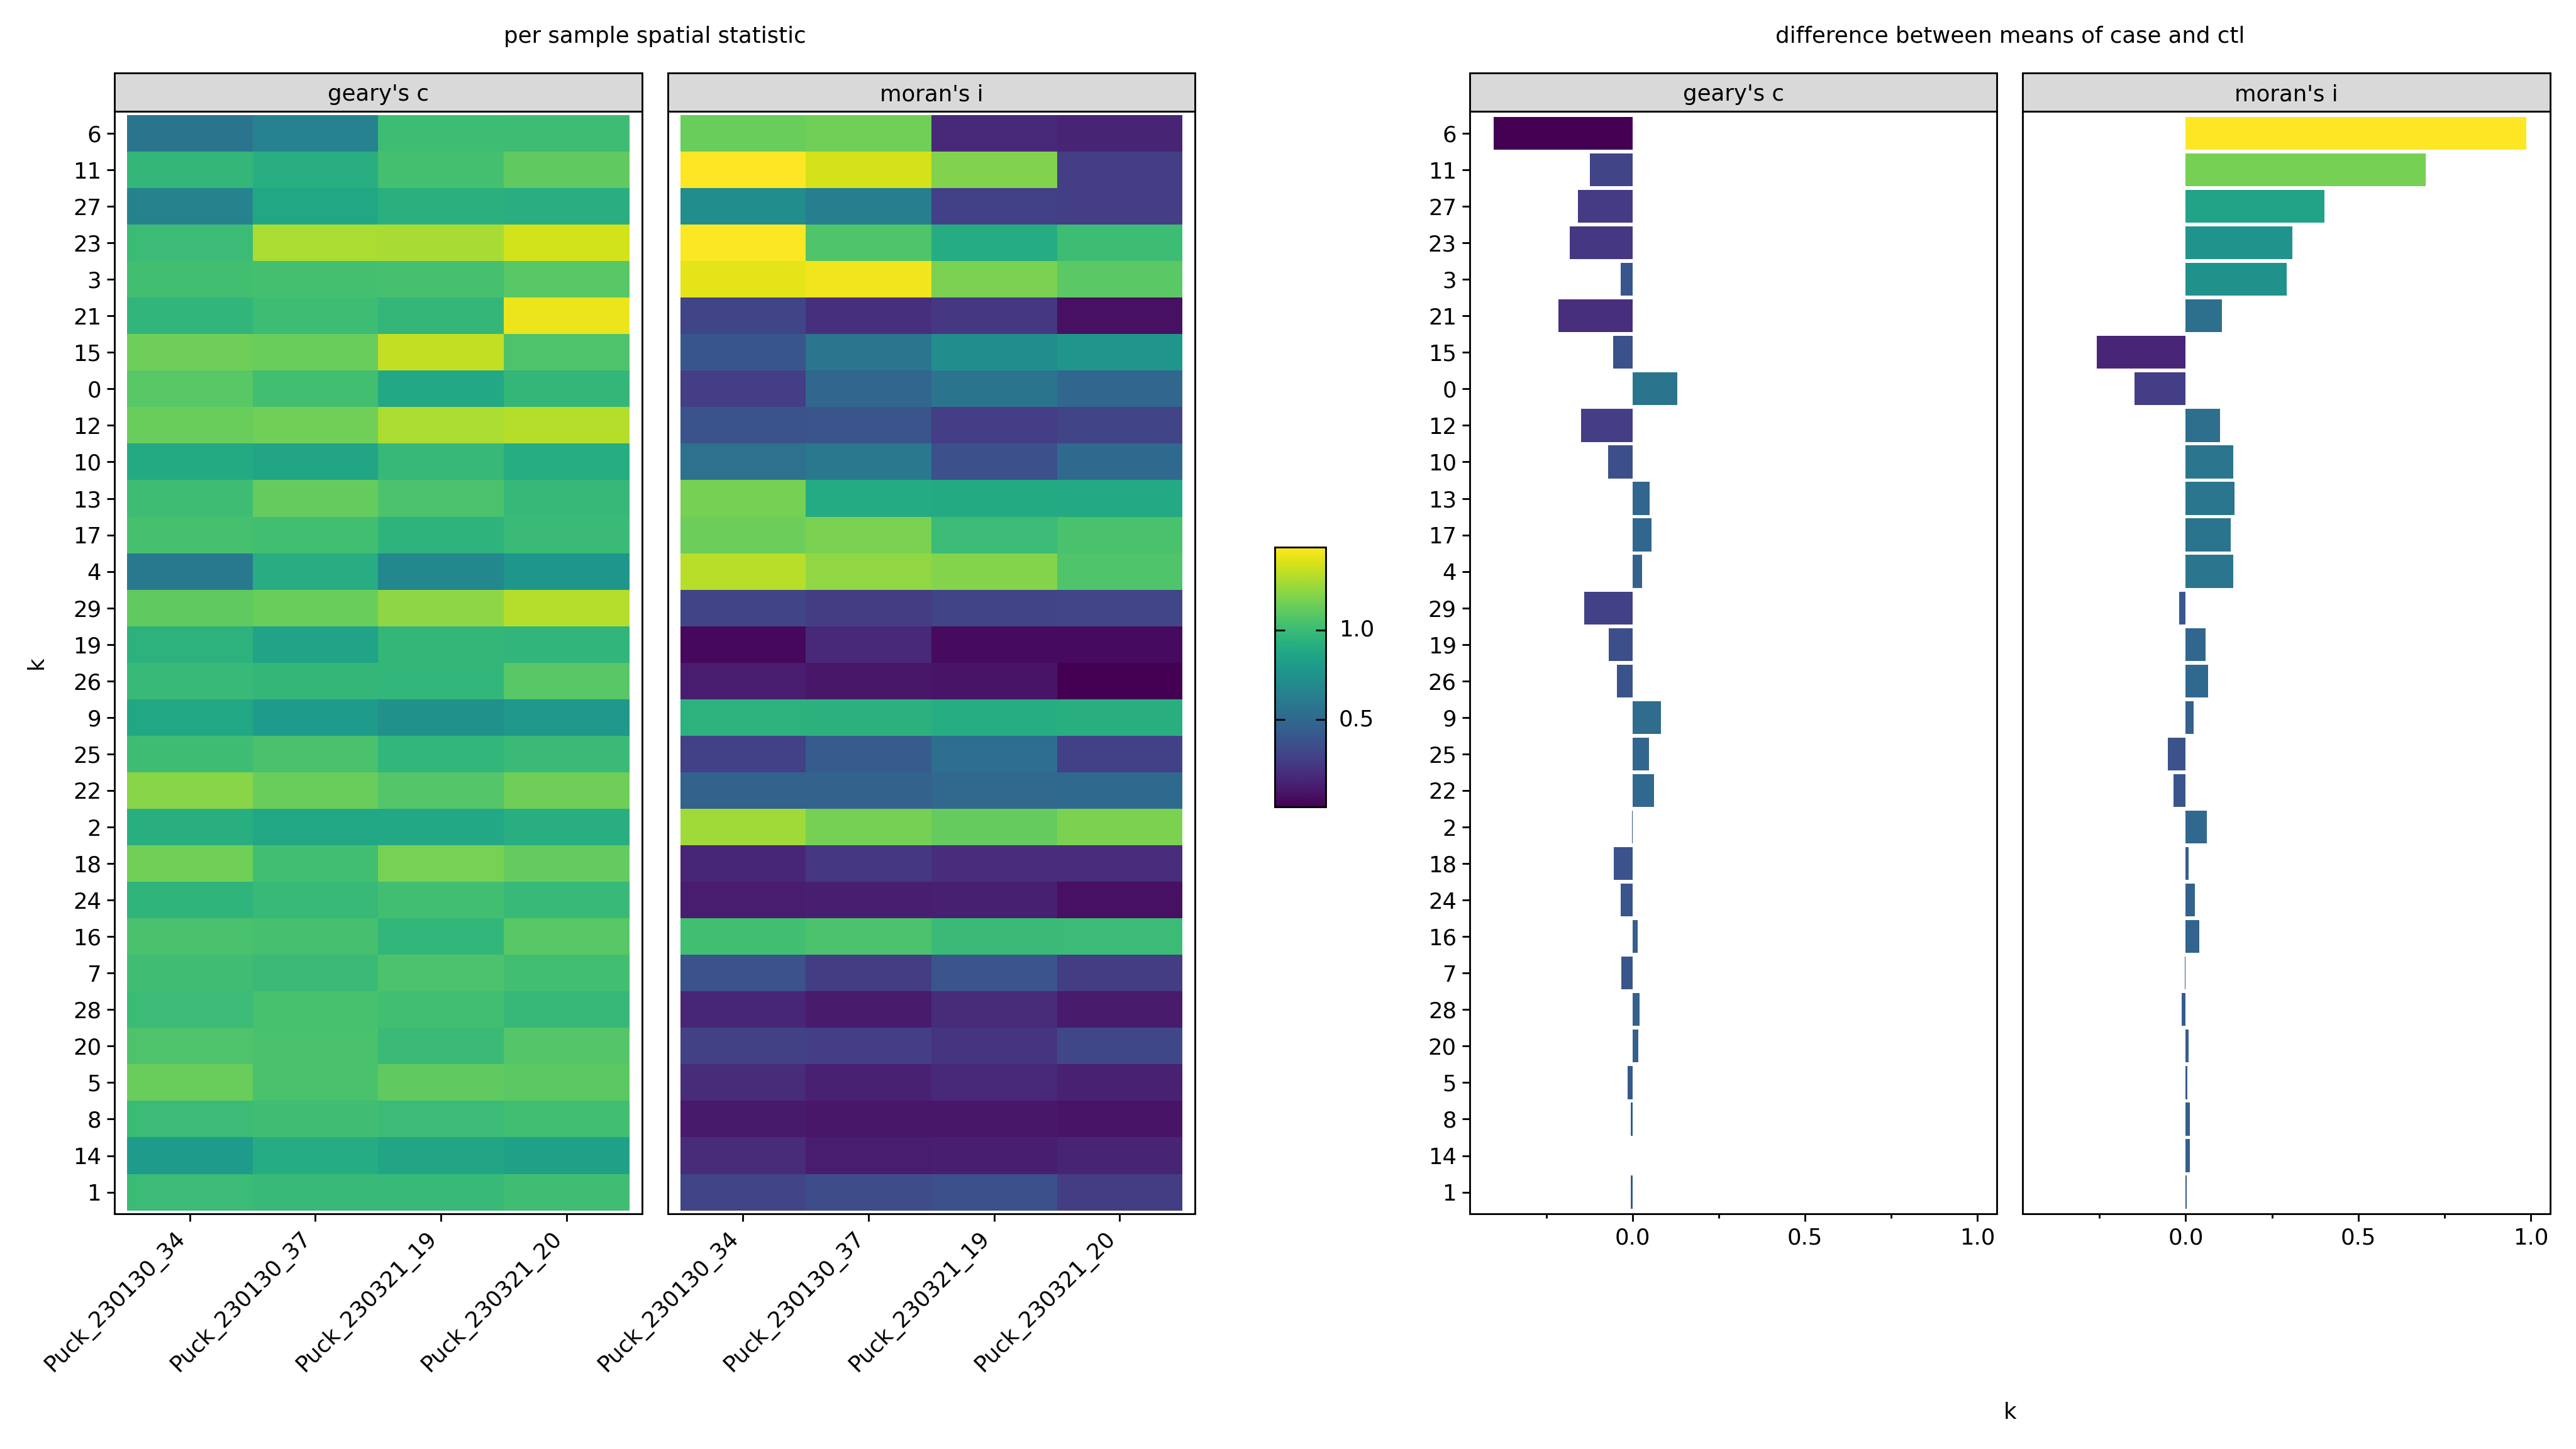

In [8]:
(sp_stat_pl & theme(figure_size=(16, 9))).show()  # ty:ignore[unsupported-operator]

we can see that factor 6 has a strong difference case-specific profile and shows interesting spatial properties
between conditions as measured by Moran's I statistic, so we plot it's distributions below:

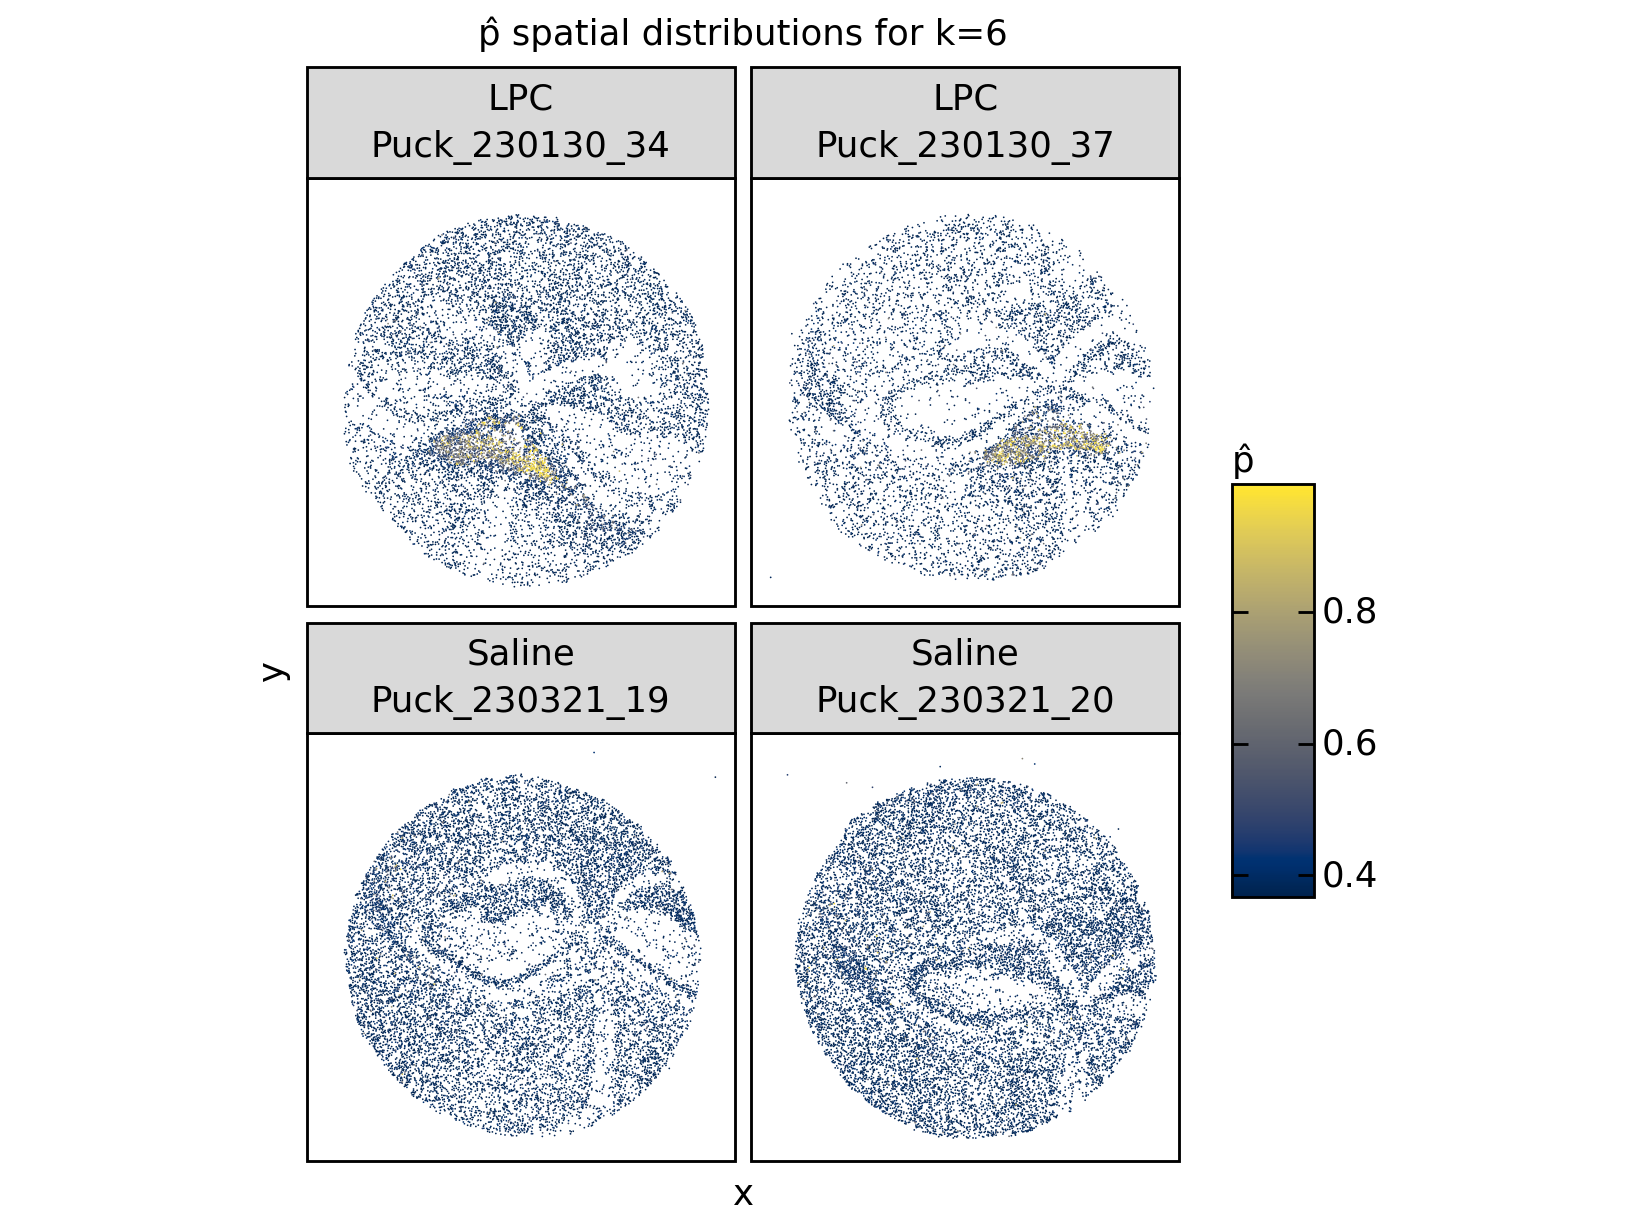

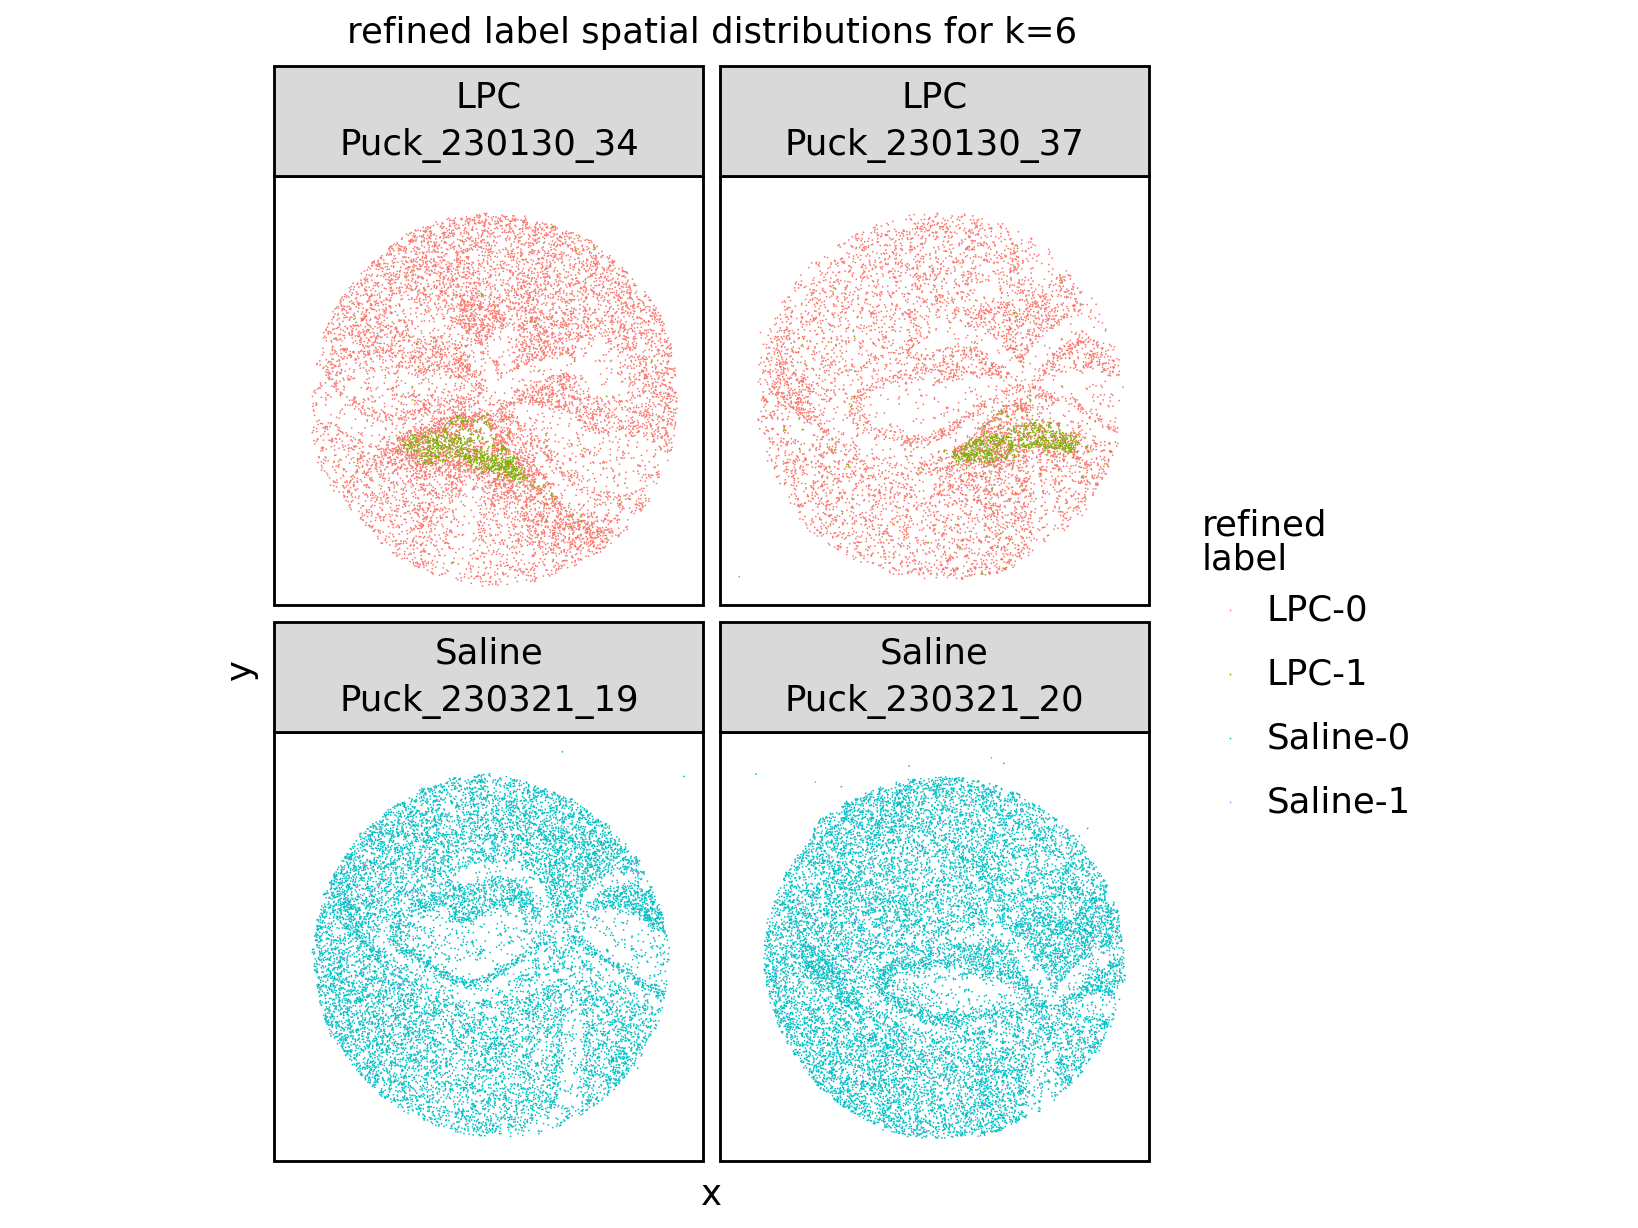

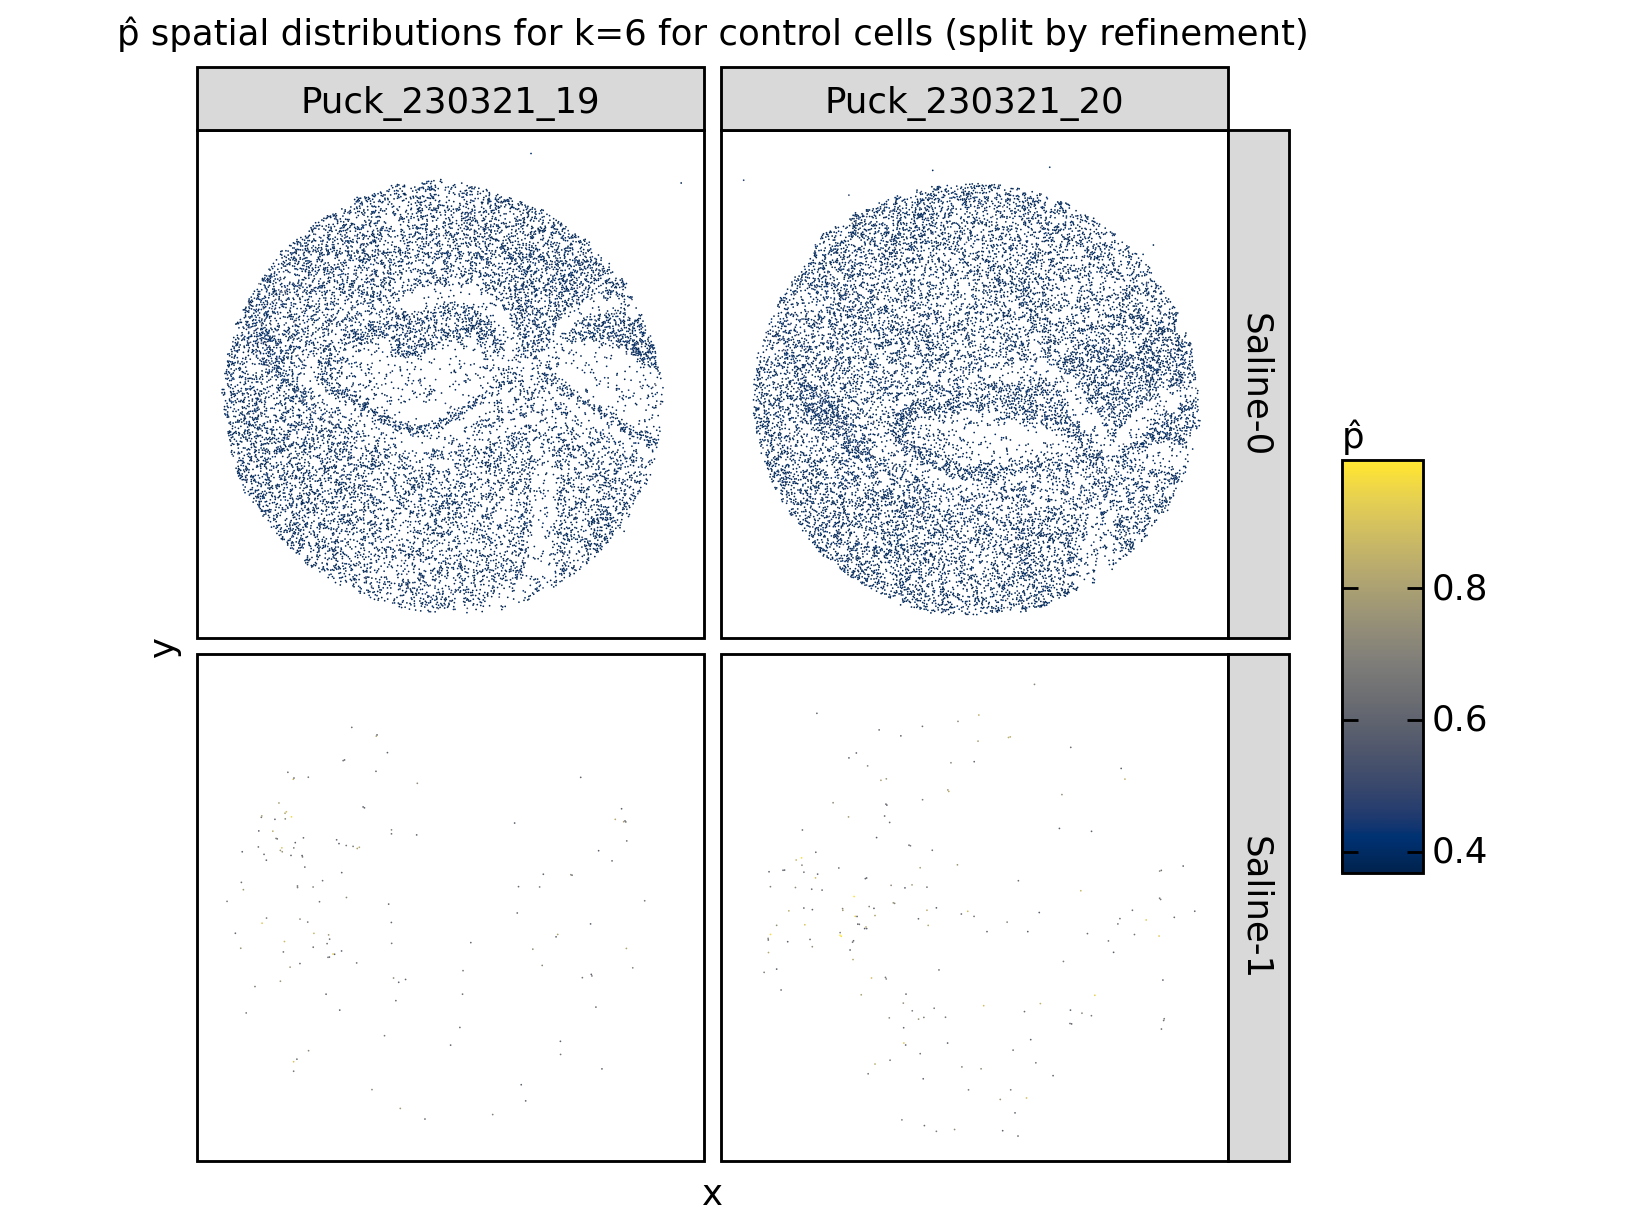

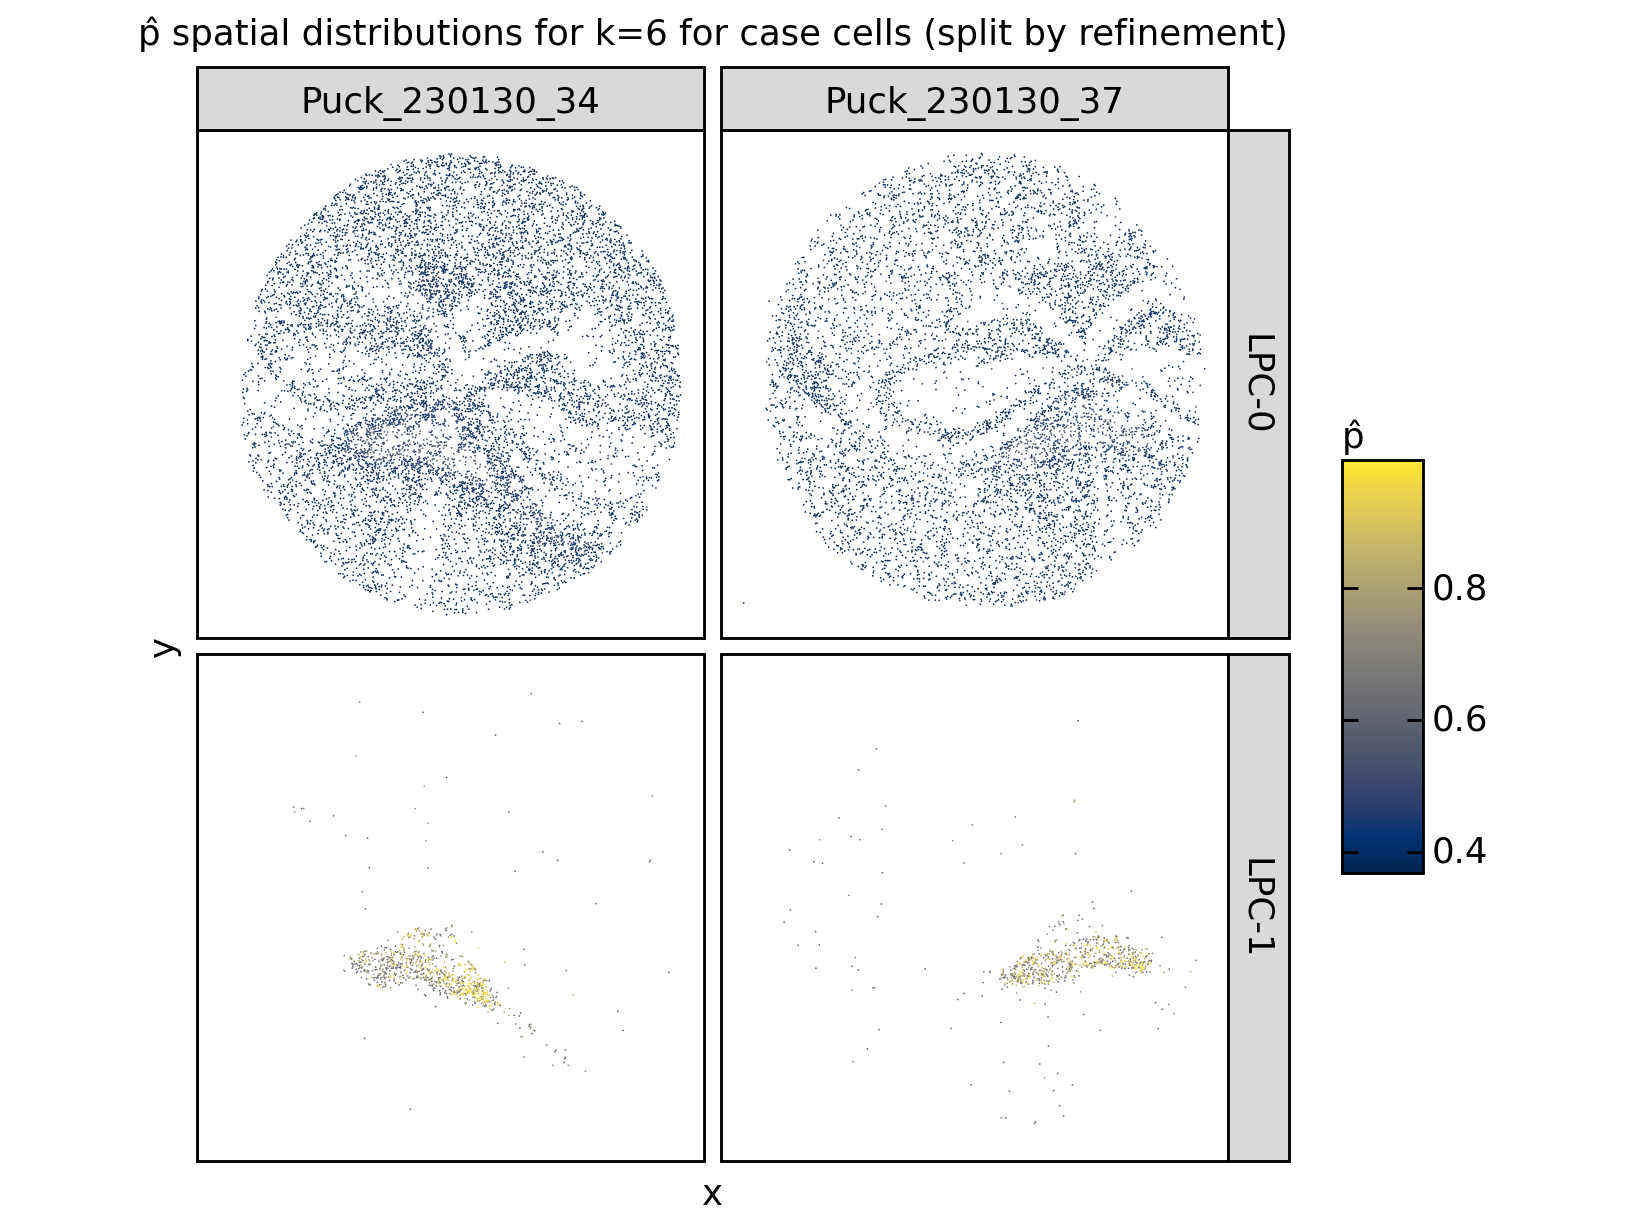

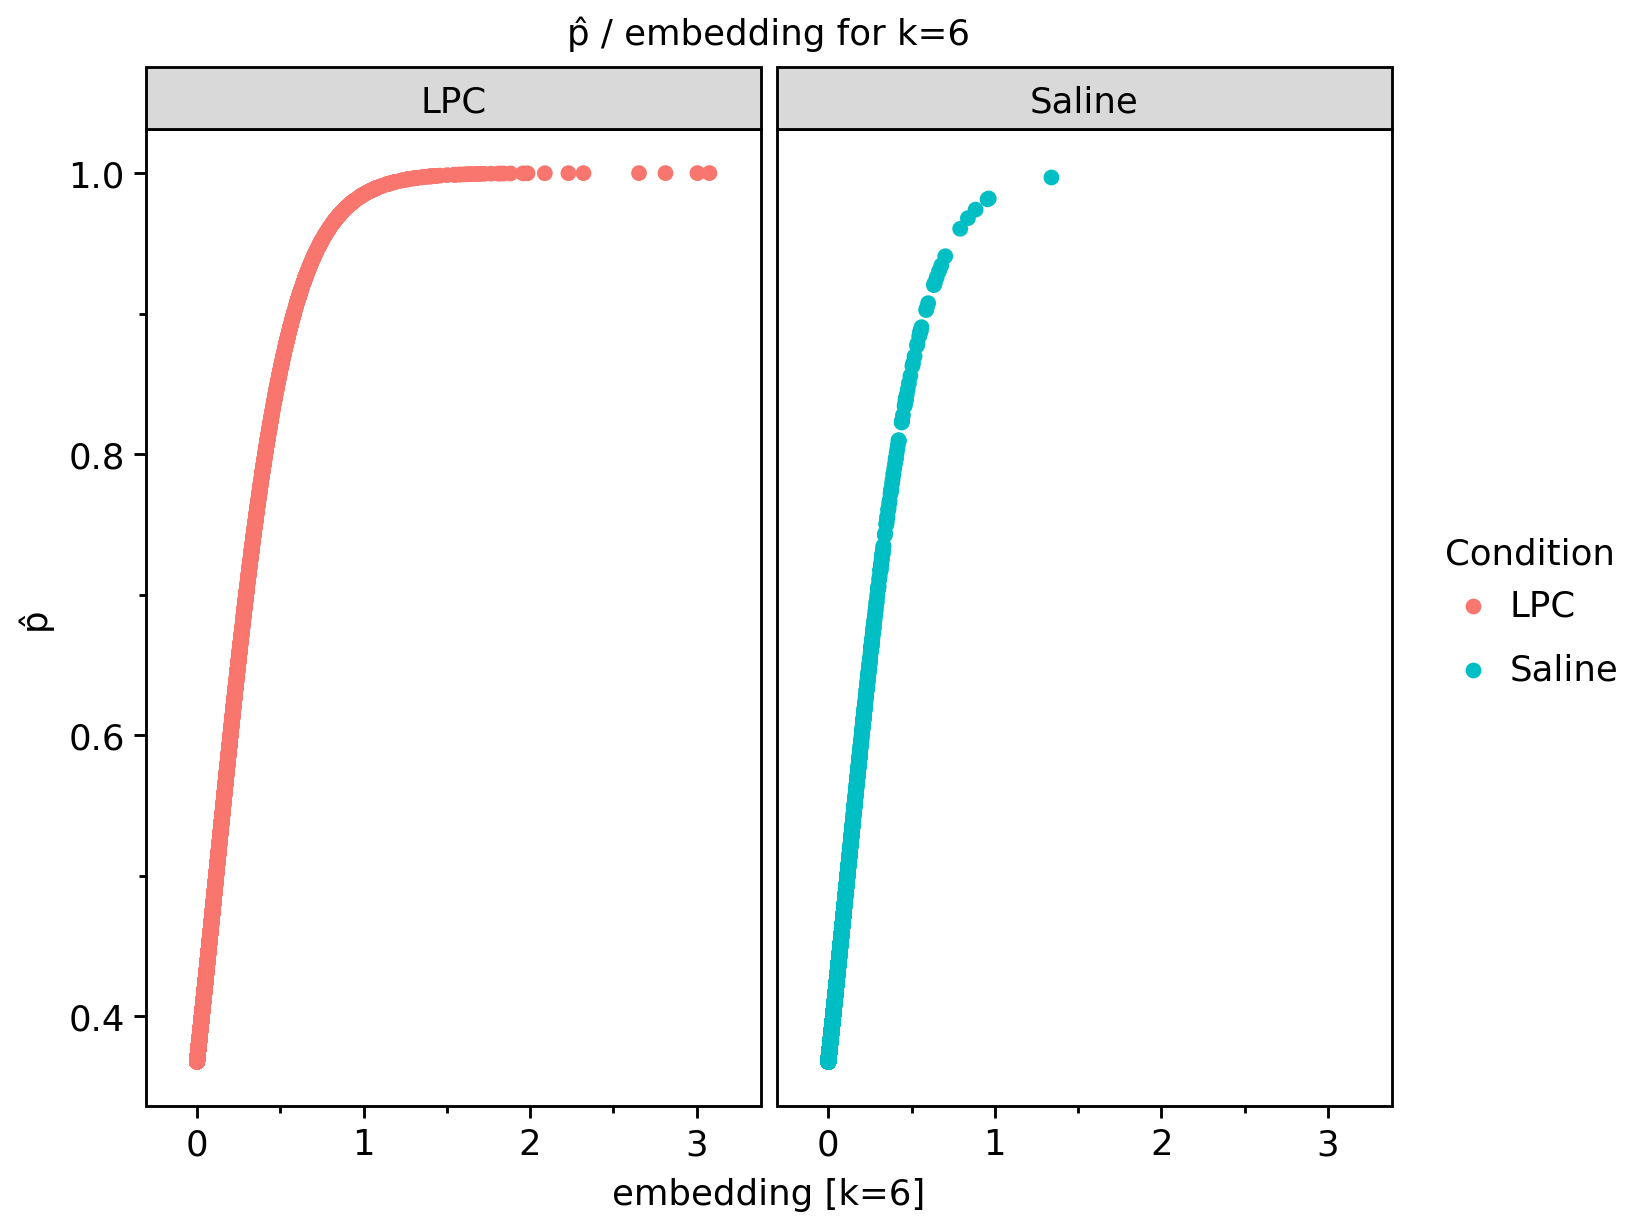

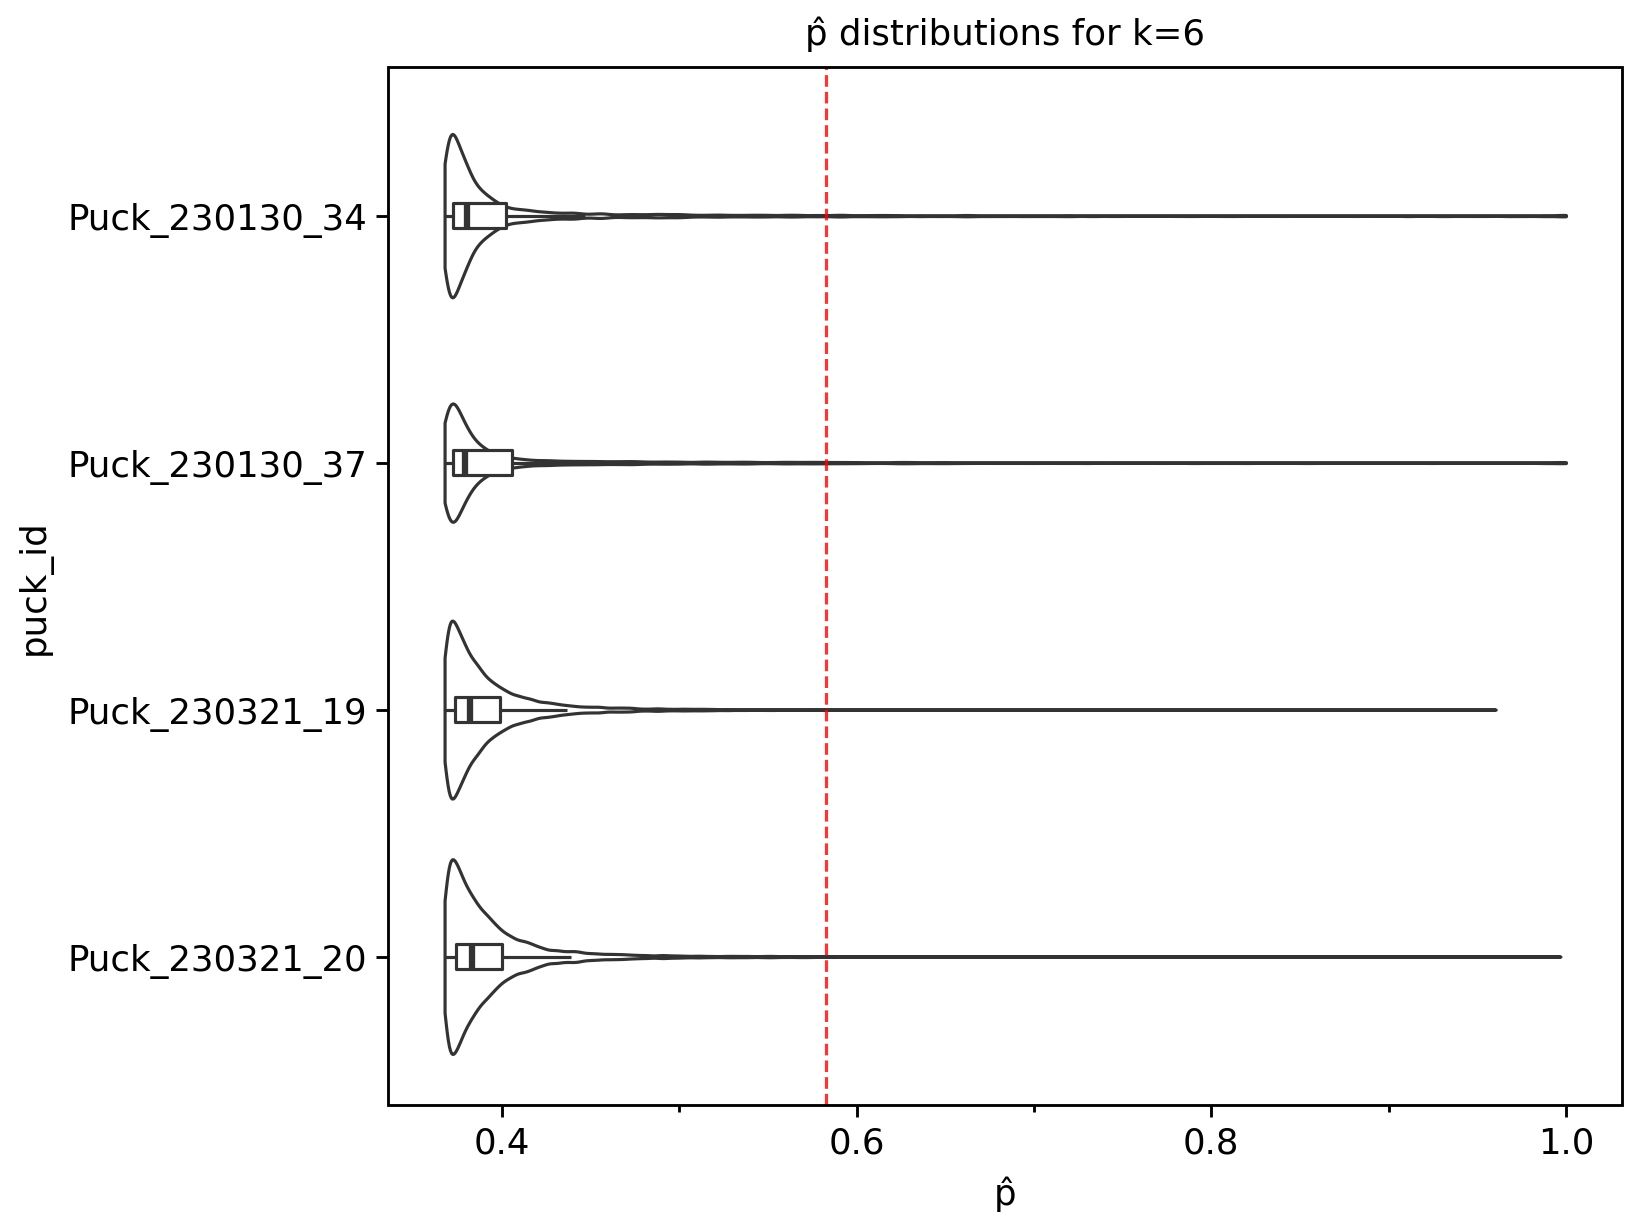

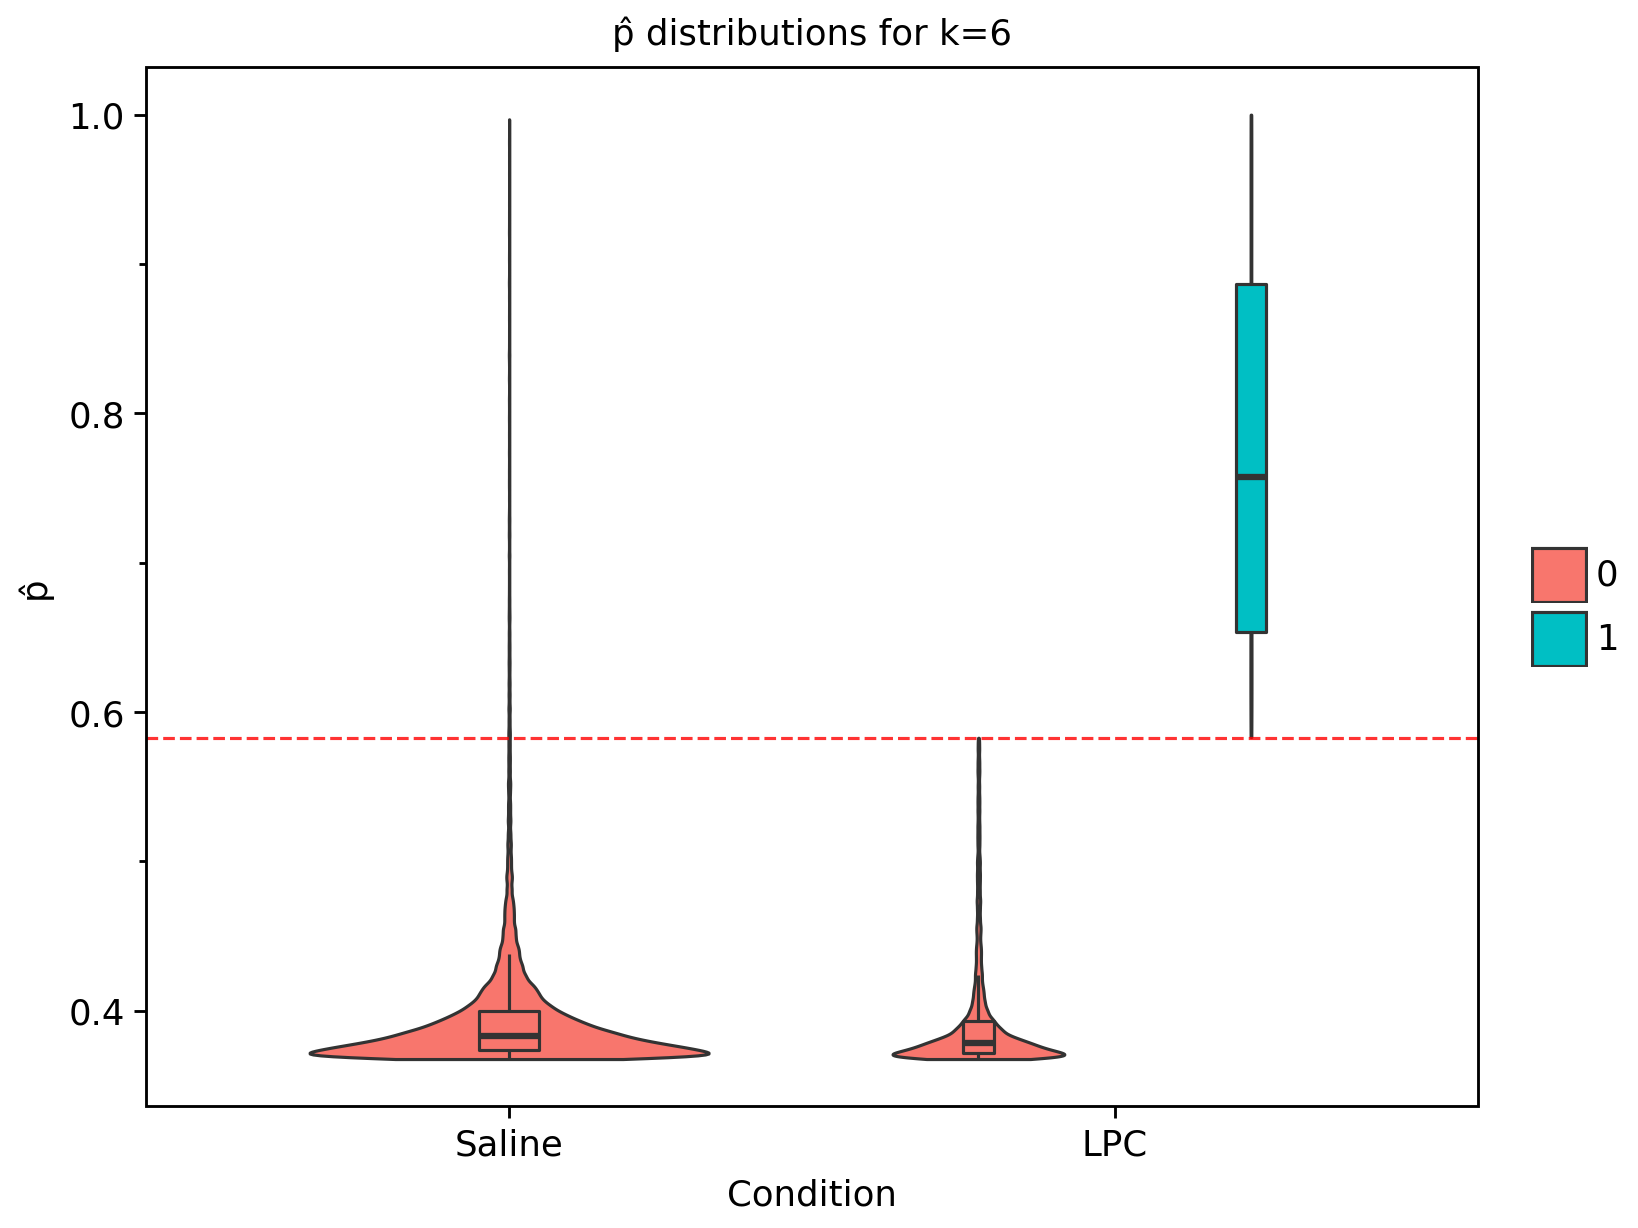

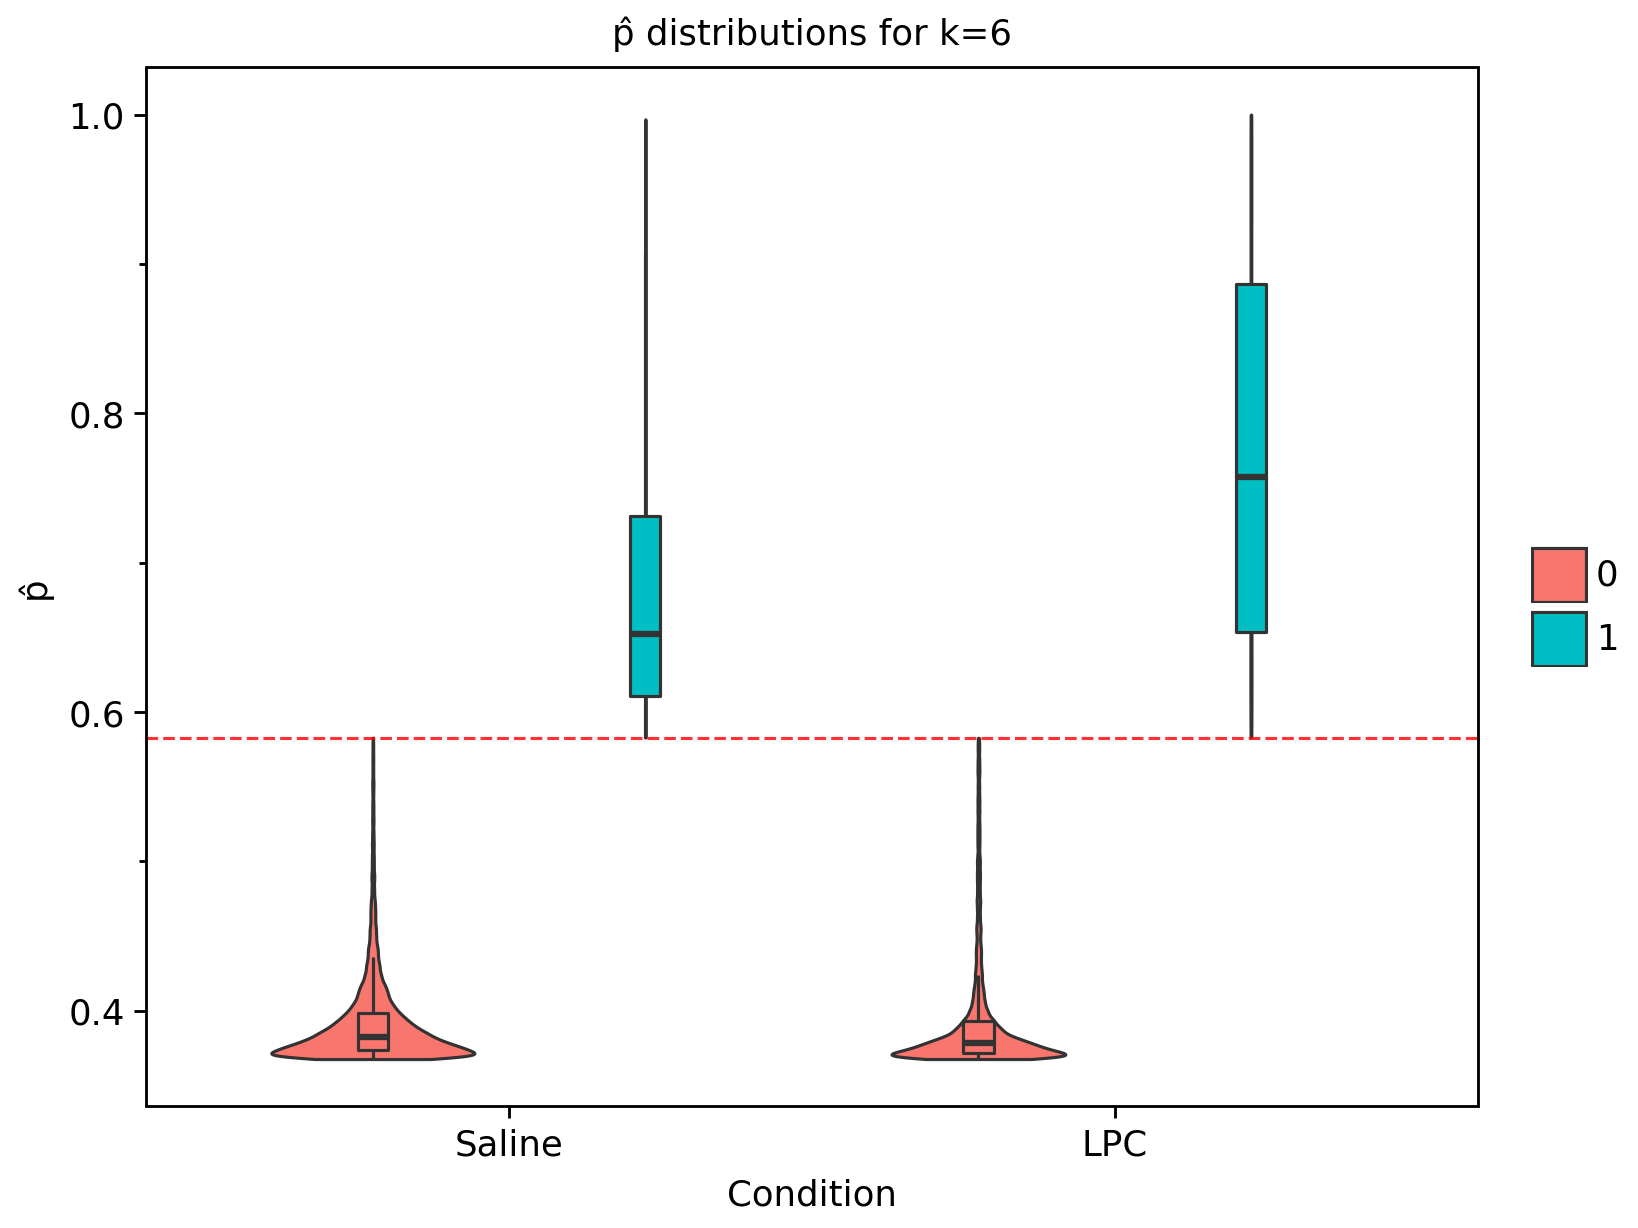

In [9]:
k = 6
for p in pl_help(rml[rml.obsm["X_nmf"][:, k] > 0, :], k).values():
    p.show()

to explore this further, we proceed w/ a gene-wise analysis for factor 6:

In [10]:
ks_oi = [6]

for k in ks_oi:
    sP.run_gene_reg(rml, SP_FACT_PAT_STR.format(k=k), SP_GENE_PAT_STR.format(k=k), layer="counts", run_reg=False)

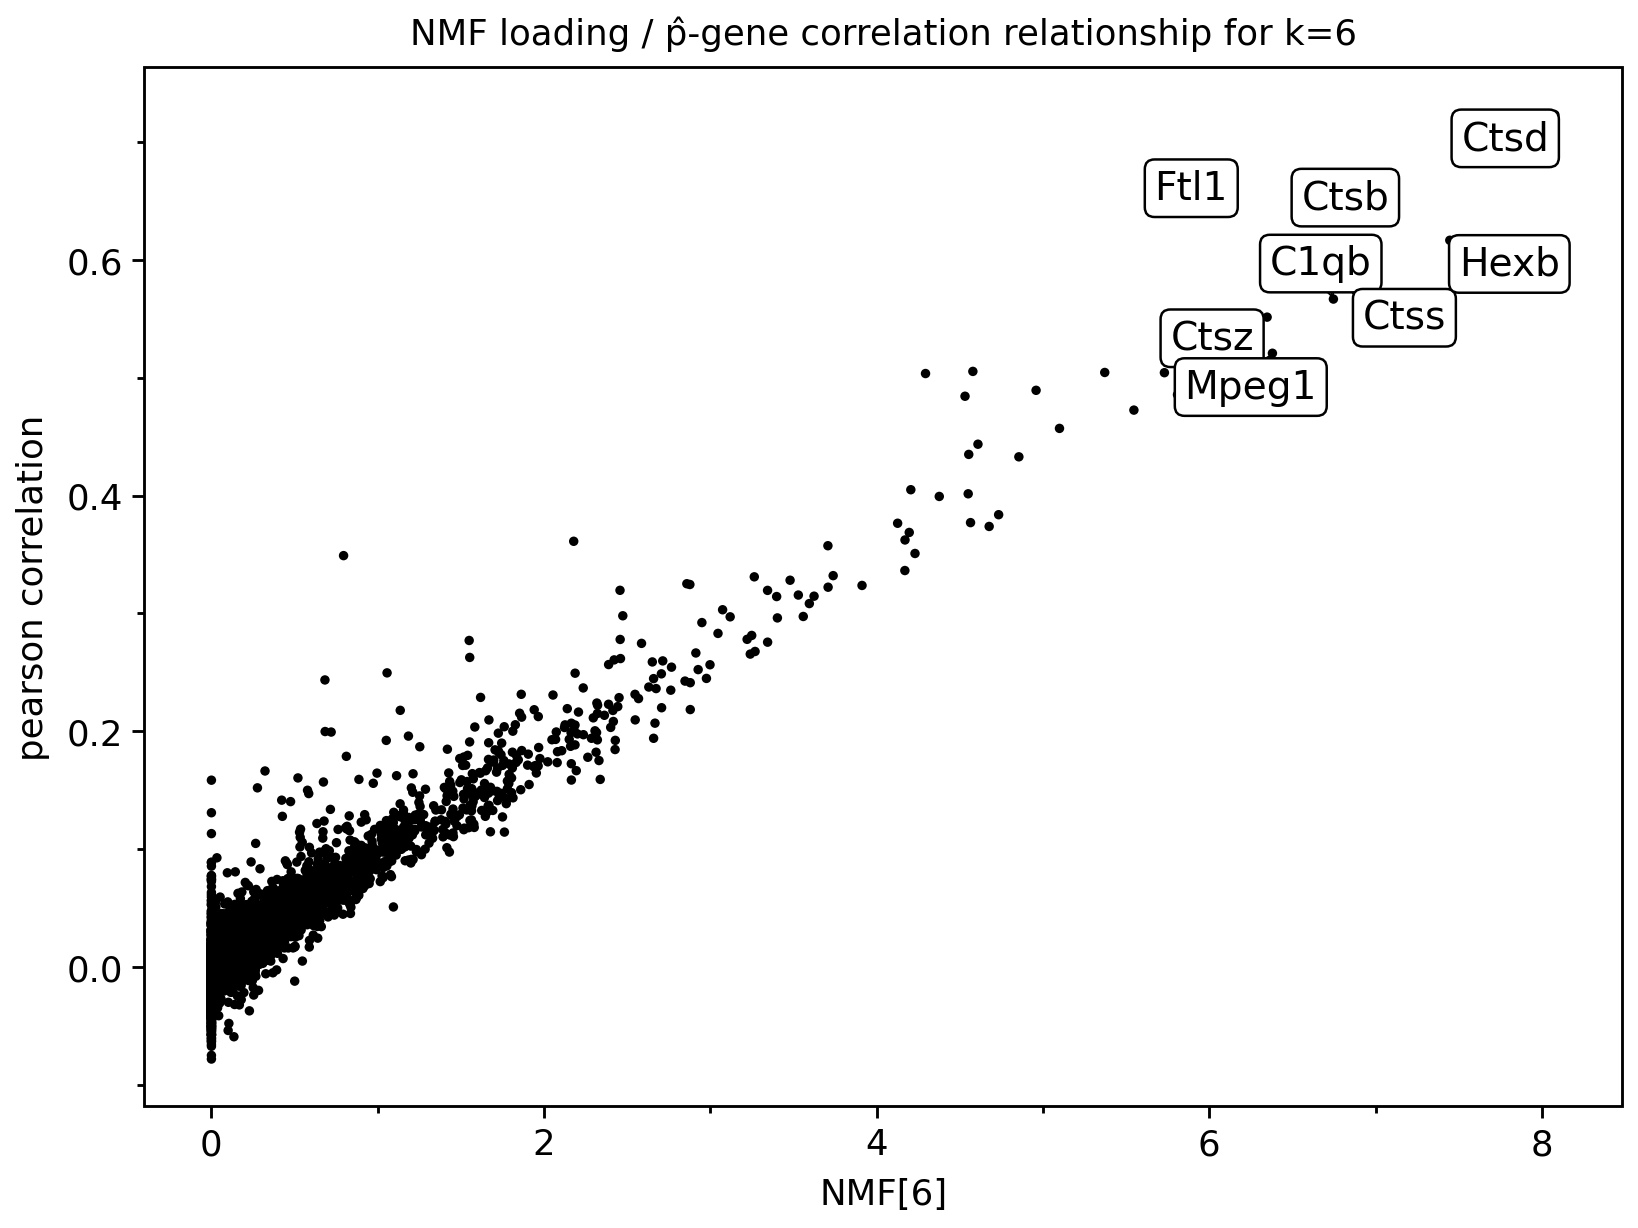

In [11]:
for k in ks_oi:
    (
        uapl.PlotAdata(rml)
        + aes(
            x=uapl.varm("X_nmf", k),
            y=uapl.varm(SP_GENE_PAT_STR.format(k=k), "corr"),
            label=np.where(
                np.argsort(np.argsort(-np.abs(np.asarray(rml.varm[SP_GENE_PAT_STR.format(k=k)]["corr"])))) < 8,
                rml.var["SYMBOL"],
                None,  # ty:ignore[invalid-argument-type]
            ),
        )
        + geom_point(size=1.5, shape="o", stroke=0)
        + geom_label(adjust_text={}, na_rm=True)
        + labs(
            colour="-log(pval)",
            x=f"NMF[{k}]",
            y="pearson correlation",
            title=f"NMF loading / p\u0302-gene correlation relationship for k={k}",
        )
    ).show()

In [12]:
degs = {k: run_deg_groups(rml, k, "Condition", "Saline") for k in ks_oi}
sig_sub = {k: degs[k].loc[lambda e: (e["adj_pval"] < 0.05) & (e["lfc"].abs() > 1)] for k in ks_oi}

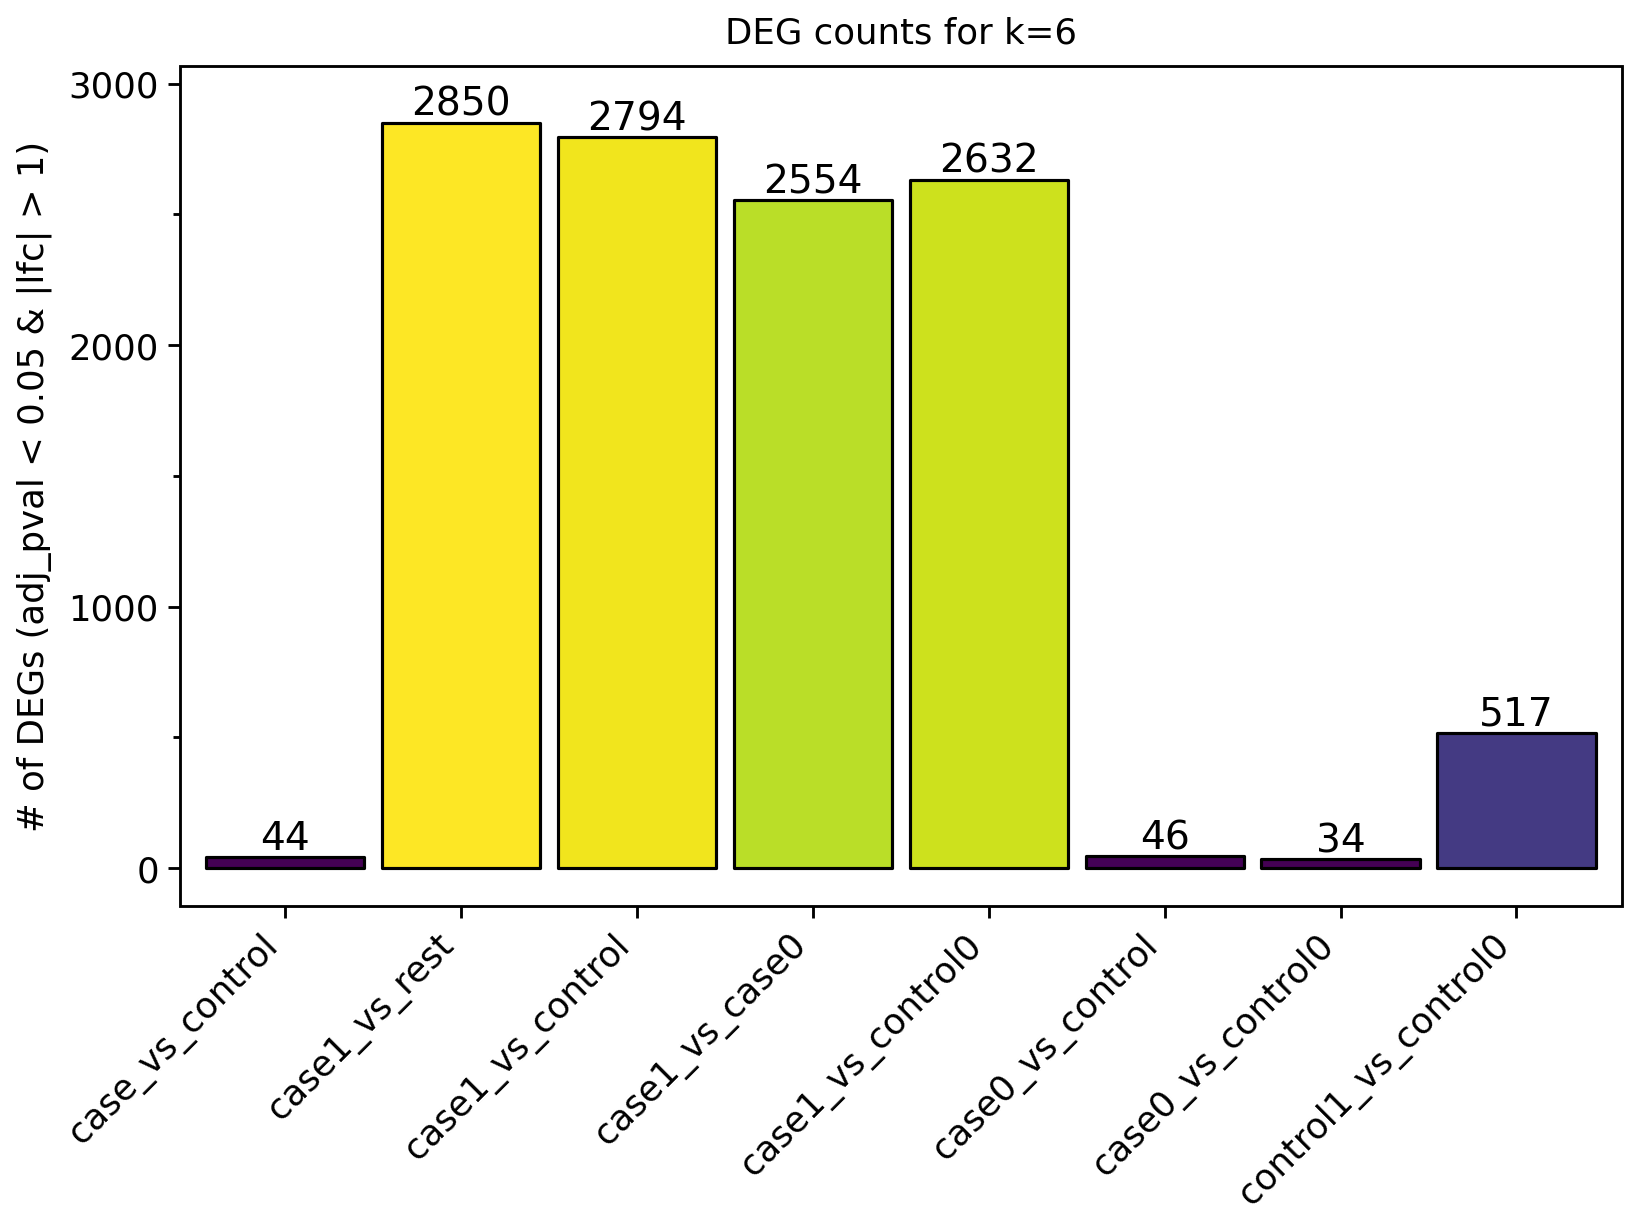

In [13]:
for k in ks_oi:
    sig_counts = sig_sub[k].groupby("cmp", observed=True)["gene"].count()
    (
        ggplot(sig_counts.reset_index(drop=False))
        + aes(x="cmp", y="gene", fill=after_stat("y"), label=after_stat("y"))
        + geom_col(color="black")
        + geom_text(nudge_y=sig_counts.max() * 0.025)
        + theme(axis_text_x=element_text(angle=45, hjust=1))
        + guides(fill="none")
        + labs(x="", y="# of DEGs (adj_pval < 0.05 & |lfc| > 1)", title=f"DEG counts for k={k}")
    ).show()

we can further visualize the permutations of gene set size in these comparisons via the upsetplot package:

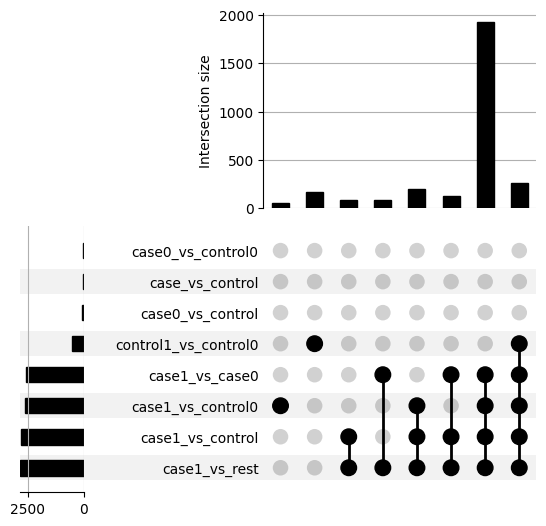

In [14]:
for k in ks_oi:
    with catch_warnings():
        simplefilter(action="ignore", category=FutureWarning)
        up.UpSet(
            up.from_contents({g: v.array for g, v in sig_sub[k].groupby("cmp", observed=True)["gene"]}),
            subset_size="count",
            max_subset_rank=8,
        ).plot()

    plt.show()